In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zipfile
from functools import reduce

In [4]:
zip_path = "fredgraph.zip"

rename_map = {
    "observation_date": "date",
    "GDP": "nominal_gdp",
    "GDPC1": "real_gdp",
    "FPCPITOTLZGUSA": "inflation_rate",
    "CPIAUCSL": "cpi",
    "UNRATE": "unemployment_rate",
    "DGS10": "yield_10yr",
    "DGS3": "yield_3yr",
    "PPAAUS00000A156NCEN": "poverty_rate",
}

csv_files = [
    "daily.csv",
    "monthly.csv",
    "quarterly.csv",
    "annual.csv",
]

dfs = []

with zipfile.ZipFile(zip_path) as z:
    for file in csv_files:
        tmp = pd.read_csv(
            z.open(file),
            na_values=[".", "", "NA", "NaN"],
        )

        tmp = tmp.rename(columns=rename_map)
        tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")

        for col in tmp.columns:
            if col != "date":
                tmp[col] = pd.to_numeric(tmp[col], errors="coerce")

        dfs.append(tmp)

df = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    dfs,
)

df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print(df.info())

        date  yield_10yr  yield_3yr    cpi  unemployment_rate  nominal_gdp  \
0 1947-01-01         NaN        NaN  21.48                NaN      243.164   
1 1947-02-01         NaN        NaN  21.62                NaN          NaN   
2 1947-03-01         NaN        NaN  22.00                NaN          NaN   
3 1947-04-01         NaN        NaN  22.00                NaN      245.968   
4 1947-05-01         NaN        NaN  21.95                NaN          NaN   

   real_gdp  inflation_rate  poverty_rate  
0  2182.681             NaN           NaN  
1       NaN             NaN           NaN  
2       NaN             NaN           NaN  
3  2176.892             NaN           NaN  
4       NaN             NaN           NaN  
<class 'pandas.DataFrame'>
RangeIndex: 17216 entries, 0 to 17215
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               17216 non-null  datetime64[us]
 1   

In [5]:
sp500 = pd.read_csv("chart_20260616T165446.csv")

In [6]:
sp500.head()

,Date,Value
0,12/31/1927,17.66
1,01/31/1928,17.57
2,02/29/1928,17.26
3,03/31/1928,19.28
4,04/30/1928,19.75


In [9]:

# df: first-of-month datetime dates
df["period"] = df["date"].dt.to_period("M")

# sp500: mm/dd/yyyy, month-end dates
sp500["Date"] = pd.to_datetime(sp500["Date"], format="%m/%d/%Y")
sp500["period"] = sp500["Date"].dt.to_period("M")
sp500 = sp500.rename(columns={"Value": "sp500"})

merged = df.merge(sp500[["period", "sp500"]], on="period", how="inner")

keep = ["yield_10yr", "yield_3yr", "inflation_rate", "sp500"]
Z = merged[["date"] + keep]   # add "sp500" here if you want the S&P column too

In [19]:
Z.head(100000)

,date,yield_10yr,yield_3yr,inflation_rate,sp500
0,1947-01-01,NaN,NaN,NaN,15.66
1,1947-02-01,NaN,NaN,NaN,15.43
2,1947-03-01,NaN,NaN,NaN,15.17
3,1947-04-01,NaN,NaN,NaN,14.58
4,1947-05-01,NaN,NaN,NaN,14.45
...,...,...,...,...,...
17211,2026-06-08,4.56,4.21,NaN,7431.46
17212,2026-06-09,4.53,4.16,NaN,7431.46
17213,2026-06-10,4.55,4.17,NaN,7431.46
17214,2026-06-11,4.45,4.09,NaN,7431.46


In [20]:
print(Z["inflation_rate"])

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
17211   NaN
17212   NaN
17213   NaN
17214   NaN
17215   NaN
Name: inflation_rate, Length: 17216, dtype: float64


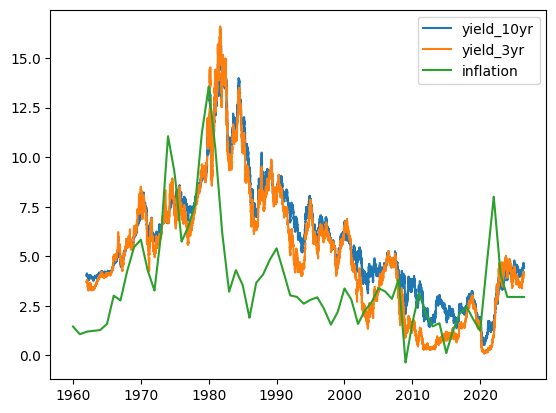

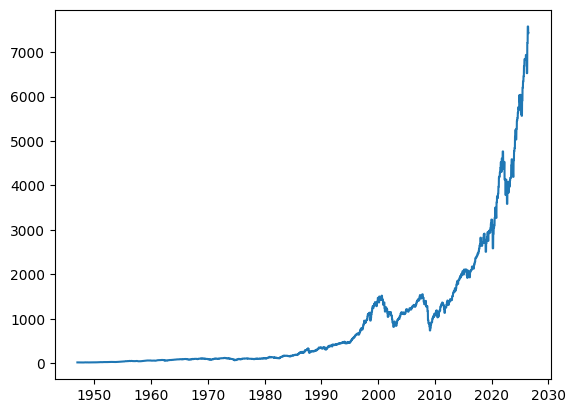

In [34]:
plt.plot(Z["date"],Z["yield_10yr"],label="yield_10yr")
plt.plot(Z["date"],Z["yield_3yr"],label="yield_3yr")
plt.plot(Z["date"],Z["inflation_rate"].interpolate(), '-',label="inflation")
plt.legend()
plt.show()

plt.plot(Z["date"],Z["sp500"])
plt.show()

In [37]:
Z["sp500_d"] = np.log(Z["sp500"]).diff()

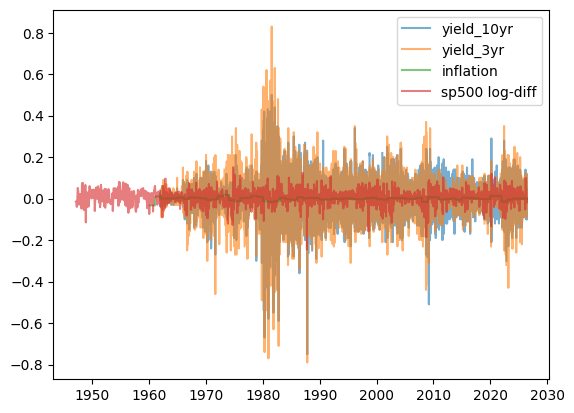

In [60]:
plt.plot(Z["date"],Z["yield_10yr"].diff(),label="yield_10yr",alpha=0.6)
plt.plot(Z["date"],Z["yield_3yr"].diff(),label="yield_3yr",alpha=0.6)
plt.plot(Z["date"],(Z["inflation_rate"]).interpolate().diff(), '-',label="inflation",alpha=0.6)
plt.plot(Z["date"],Z["sp500_d"],label="sp500 log-diff",alpha=0.6)

plt.legend()
plt.show()
plt.show()

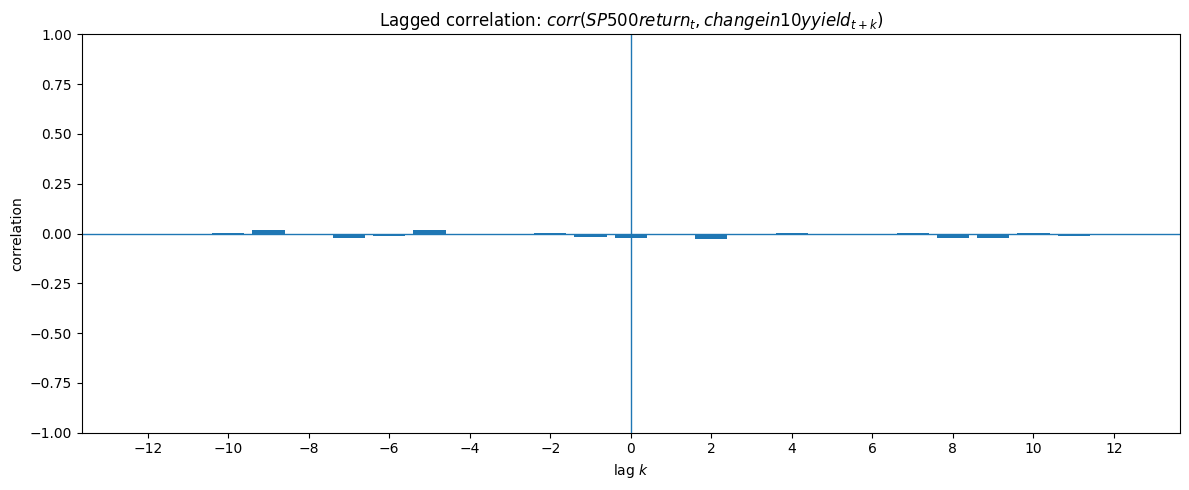

    lag      corr      n
14    2 -0.029788  15194
21    9 -0.024079  15194
5    -7 -0.021893  15187
12    0 -0.020592  15194
20    8 -0.020136  15194
7    -5  0.018653  15189
11   -1 -0.018438  15193
3    -9  0.015611  15185
23   11 -0.011353  15194
6    -6 -0.010664  15188


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_lagged_corr(X, Y, max_lag=12, x_name="X", y_name="Y", min_obs=10):
    """
    Plots:
        corr(X_t, Y_{t+k}), k = -max_lag, ..., max_lag

    Interpretation:
        k > 0: X_t is correlated with future Y
        k < 0: X_t is correlated with past Y
        k = 0: contemporaneous correlation
    """

    x = pd.Series(X).reset_index(drop=True)
    y = pd.Series(Y).reset_index(drop=True)

    if len(x) != len(y):
        raise ValueError("X and Y must have the same length.")

    rows = []

    for k in range(-max_lag, max_lag + 1):
        tmp = pd.DataFrame({
            "x_t": x,
            "y_t_plus_k": y.shift(-k)
        }).dropna()

        if len(tmp) < min_obs:
            corr = np.nan
        else:
            corr = tmp["x_t"].corr(tmp["y_t_plus_k"])

        rows.append({
            "lag": k,
            "corr": corr,
            "n": len(tmp)
        })

    out = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(out["lag"], out["corr"])
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    ax.set_title(rf"Lagged correlation: $corr({x_name}_t, {y_name}_{{t+k}})$")
    ax.set_xlabel(r"lag $k$")
    ax.set_ylabel("correlation")
    ax.set_xticks(range(-max_lag, max_lag + 1, 2))
    ax.set_ylim(-1, 1)

    plt.tight_layout()
    plt.show()

    return out

ccf_xy = plot_lagged_corr(
    X=Z["sp500_d"],
    Y=Z["yield_10yr"].diff(),
    max_lag=12,
    x_name="SP500 return",
    y_name="change in 10y yield"
)

print(ccf_xy.sort_values("corr", key=lambda s: s.abs(), ascending=False).head(10))

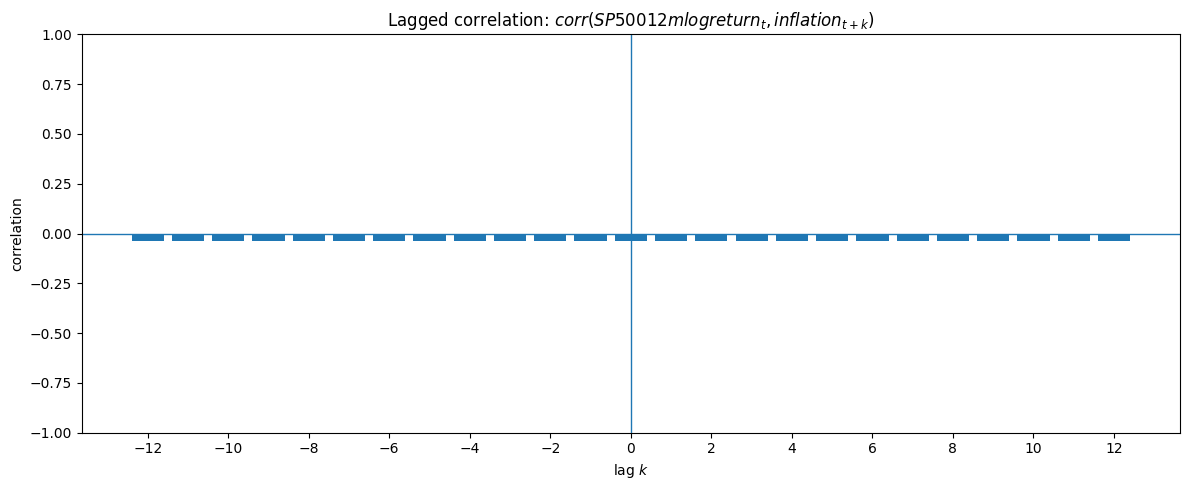

   lag      corr      n
0  -12 -0.039117  17048
1  -11 -0.039007  17049
2  -10 -0.038858  17050
3   -9 -0.038651  17051
4   -8 -0.038458  17052
5   -7 -0.038283  17053
6   -6 -0.038026  17054
7   -5 -0.037866  17055
8   -4 -0.037661  17056
9   -3 -0.037434  17057


In [68]:
Z2 = Z.copy()
Z2["date"] = pd.to_datetime(Z2["date"])
Z2 = Z2.sort_values("date")

# S&P 500 log return
Z2["sp500_ret"] = Z2["sp500_d"]

# Rolling 12-period cumulative log return
Z2["sp500_ret_12m"] = Z2["sp500_ret"].rolling(12, min_periods=12).sum()

# Alternative smoother: rolling average return
Z2["sp500_ret_12m_avg"] = Z2["sp500_ret"].rolling(12, min_periods=12).mean()

# Inflation level
Z2["inflation"] = Z2["inflation_rate"].interpolate()

# Inflation change
Z2["d_inflation"] = Z2["inflation"].diff()

tmp = Z2[["sp500_ret_12m", "inflation"]].dropna()

ccf_sp500_inflation = plot_lagged_corr(
    X=tmp["sp500_ret_12m"],
    Y=tmp["inflation"],
    max_lag=12,
    x_name="SP500 12m log return",
    y_name="inflation"
)

print(
    ccf_sp500_inflation
    .sort_values("corr", key=lambda s: s.abs(), ascending=False)
    .head(10)
)